# 혈액 부족 예측 및 헌혈 운영 최적화 — AI 에이전트

> **UNIST Industrial Operations Management Term Project**  
> Team 2: 노우찬 · 손준영 · 민예지

---

## Phase 0: 데이터 전처리 파이프라인

원시 CSV 7개를 분석 가능한 형태로 정제하고, 에이전트가 사용할 임계값과 피처를 생성합니다.

| 단계 | 파일 | 내용 |
|------|------|------|
| **0-0** | — | 라이브러리 임포트, 경로 설정 |
| **0-1** | 파일 5 | 일별 혈액 보유량 → 날짜 인덱스 시계열 |
| **0-2** | 파일 6 | 월별 혈액 보유량(제제별) → Long format |
| **0-3** | 파일 2 | 월별 헌혈통계 → 전국 합계 시계열 |
| **0-4** | 파일 3 | 연도별 헌혈자 수 → 깔끔한 DataFrame |
| **0-5** | — | 피처 엔지니어링 (계절·위험시즌 변수) |
| **0-6** | — | 안전재고 임계값 설정 및 위험 등급 함수 |
| **0-7** | — | 처리된 파일 저장 및 최종 요약 |

---
### Phase 0-0: 라이브러리 임포트 및 경로 설정

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE      = r'C:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project'
PROCESSED = os.path.join(BASE, 'processed')
os.makedirs(PROCESSED, exist_ok=True)

print('✅ 라이브러리 로드 완료')
print(f'📁 원본 데이터: {BASE}')
print(f'📁 저장 경로:   {PROCESSED}')

---
### Phase 0-1: 일별 혈액 보유량 (파일 5)

- **원본**: `5.Blood_retention_trends_for_blood_transfusion(Day).csv`
- **형태**: Wide format — 날짜(366행) × 연도(2015–2025)
- **목적**: 에이전트 예측 모듈의 핵심 시계열 → Long format으로 변환

In [ ]:
df5_raw = pd.read_csv(
    f'{BASE}/5.Blood_retention_trends_for_blood_transfusion(Day).csv',
    encoding='cp949', header=None
)

# 헤더 행에서 연도 목록 추출
years     = df5_raw.iloc[0, 1:].astype(str).str.strip().tolist()   # ['2015', ..., '2025']
date_strs = df5_raw.iloc[1:, 0].tolist()                           # ['01월 01일', ...]

# Wide → Long 변환
records = []
for col_offset, yr in enumerate(years):
    col_idx = col_offset + 1
    for row_offset, date_str in enumerate(date_strs):
        val_raw = df5_raw.iloc[row_offset + 1, col_idx]
        val = pd.to_numeric(str(val_raw).replace(',', ''), errors='coerce')

        # '01월 01일' → '2015-01-01'
        md = str(date_str).strip().replace('월 ', '-').replace('일', '').strip()
        try:
            date = pd.to_datetime(f'{yr}-{md}', format='%Y-%m-%d')
            if pd.notna(val):
                records.append({'date': date, 'year': int(yr), 'inventory': val})
        except Exception:
            pass  # 윤년 아닌 해의 2월 29일 등 무시

daily_inventory = (
    pd.DataFrame(records)
    .dropna(subset=['inventory'])
    .sort_values('date')
    .reset_index(drop=True)
)
daily_inventory['inventory'] = daily_inventory['inventory'].astype(int)

print(f'✅ 일별 보유량: {len(daily_inventory):,}행')
print(f'   기간: {daily_inventory["date"].min().date()} ~ {daily_inventory["date"].max().date()}')
print(f'   범위: {daily_inventory["inventory"].min():,} ~ {daily_inventory["inventory"].max():,} unit')
print()
print('연도별 평균 보유량 (unit):')
print(daily_inventory.groupby('year')['inventory'].mean().round(0).astype(int).to_string())

In [ ]:
# 전체 일별 시계열 시각화
ts = daily_inventory.set_index('date')['inventory']

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts.values, color='steelblue', linewidth=0.7, alpha=0.8)
ax.axhline(y=20000, color='orange', linestyle='--', linewidth=1.2, label='주의선 (20,000)')
ax.axhline(y=15000, color='red',    linestyle='--', linewidth=1.2, label='경고선 (15,000)')
ax.axhline(y=10000, color='darkred',linestyle=':',  linewidth=1.2, label='위기선 (10,000)')
ax.set_title('일별 혈액 보유량 (2015–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('보유량 (unit)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
### Phase 0-2: 월별 혈액 보유량 — 제제별 (파일 6)

- **원본**: `6.Blood_retention_trends_for_blood_transfusion(Month).csv`
- **형태**: 월(12행) × [연도 × 제제](44열)
- **제제 4종**: 농축적혈구(RBC) · 농축혈소판(PLT) · 신선동결혈장(FFP) · 백혈구여과제거성분채혈혈소판(SDP)
- **목적**: 제제별 부족 위험도 개별 평가 (혈소판 유효기간 5일 → 별도 모니터링)

In [ ]:
df6_raw = pd.read_csv(
    f'{BASE}/6.Blood_retention_trends_for_blood_transfusion(Month).csv',
    encoding='cp949', header=None
)

# 헤더 추출
years_row = df6_raw.iloc[0, 1:].astype(str).str.strip().tolist()
types_row = df6_raw.iloc[1, 1:].astype(str).str.strip().tolist()
months    = df6_raw.iloc[2:, 0].tolist()       # ['1월', ..., '12월']
data_mat  = df6_raw.iloc[2:, 1:].reset_index(drop=True)

# 영문 코드 매핑
COMP_CODE = {
    '농축적혈구':              'RBC',
    '농축혈소판':              'PLT',
    '신선동결혈장':             'FFP',
    '백혈구여과제거성분채혈혈소판': 'SDP',
}

records = []
for col_offset, (yr, comp) in enumerate(zip(years_row, types_row)):
    for row_offset, mo_str in enumerate(months):
        val_raw  = data_mat.iloc[row_offset, col_offset]
        val      = pd.to_numeric(str(val_raw).replace(',', ''), errors='coerce')
        month_num = int(str(mo_str).replace('월', '').strip())
        records.append({
            'year':           int(str(yr).strip()),
            'month':          month_num,
            'component':      comp,
            'component_code': COMP_CODE.get(comp, comp),
            'inventory':      val,
        })

monthly_by_type = (
    pd.DataFrame(records)
    .dropna(subset=['inventory'])
    .reset_index(drop=True)
)
monthly_by_type['date'] = pd.to_datetime(
    monthly_by_type.apply(
        lambda r: f"{int(r['year'])}-{int(r['month']):02d}-01", axis=1
    )
)

print(f'✅ 제제별 월별 보유량: {len(monthly_by_type):,}행')
print(f'   제제 종류: {monthly_by_type["component_code"].unique().tolist()}')
print(f'   기간: {monthly_by_type["year"].min()} ~ {monthly_by_type["year"].max()}')
print()

# 제제별 연평균 보유량
pivot = monthly_by_type.groupby(['year', 'component_code'])['inventory'].mean().round(0).unstack()
print('제제별 연평균 보유량:')
print(pivot.astype(int).to_string())

In [ ]:
# 제제별 월별 보유량 트렌드 (2020–2025)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=False)
codes  = ['RBC', 'PLT', 'FFP', 'SDP']
titles = ['농축적혈구 (RBC)', '농축혈소판 (PLT)', '신선동결혈장 (FFP)', '성분채혈혈소판 (SDP)']
colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']

for ax, code, title, color in zip(axes.flat, codes, titles, colors):
    df_sub = monthly_by_type[
        (monthly_by_type['component_code'] == code) &
        (monthly_by_type['year'] >= 2020)
    ].sort_values('date')
    ax.plot(df_sub['date'], df_sub['inventory'], color=color, linewidth=1.2)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('제제별 월별 보유량 추이 (2020–2025)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Phase 0-3: 월별 헌혈통계 — 전국 합계 (파일 2)

- **원본**: `2.Month_blood.csv`
- **형태**: 3행 복합 헤더 + 지역·성별별 데이터
- **추출**: 전국 합계(계) 행 — 월별 헌혈 건수 시계열
- **목적**: 헌혈량과 보유량의 상관 분석, 계절 헌혈 패턴 파악

In [ ]:
df2_raw = pd.read_csv(
    f'{BASE}/2.Month_blood.csv',
    encoding='cp949', header=None
)

# 복합 헤더 파싱 (행 0=연도, 행 1=월, 행 2=지표)
years_row   = df2_raw.iloc[0, 3:].tolist()
months_row  = df2_raw.iloc[1, 3:].tolist()
metrics_row = df2_raw.iloc[2, 3:].tolist()

# 전국 합계 행 (행 3: 혈액원=합계, 소계, 성별=계)
national_vals = df2_raw.iloc[3, 3:].tolist()

records = []
for yr, mo, metric, val in zip(years_row, months_row, metrics_row, national_vals):
    yr_str     = str(yr).strip()
    mo_str     = str(mo).strip()
    metric_str = str(metric).strip()

    # 월별 실적(건)만 추출 — 연간합계 열과 구성비 열 제외
    if metric_str == '실적 (건)' and mo_str not in ('합계', 'nan', ''):
        try:
            month_num = int(mo_str.replace('월', '').strip())
            val_clean = int(pd.to_numeric(str(val).replace(',', ''), errors='coerce'))
            records.append({'year': int(yr_str), 'month': month_num, 'donation': val_clean})
        except Exception:
            pass

monthly_donation = pd.DataFrame(records).dropna().reset_index(drop=True)
monthly_donation['date'] = pd.to_datetime(
    monthly_donation.apply(
        lambda r: f"{int(r['year'])}-{int(r['month']):02d}-01", axis=1
    )
)

print(f'✅ 월별 헌혈통계(전국): {len(monthly_donation):,}행')
print(f'   기간: {monthly_donation["year"].min()}년 ~ {monthly_donation["year"].max()}년')
print(f'   월 평균 헌혈 건수: {monthly_donation["donation"].mean():,.0f}건')
print()

# 월별 평균 헌혈량 (계절 패턴 확인)
monthly_avg = monthly_donation.groupby('month')['donation'].mean().round(0).astype(int)
print('월별 평균 헌혈량 (2015–2025 평균):')
for m, v in monthly_avg.items():
    bar = '█' * (v // 10000)
    print(f'  {m:2d}월: {v:,}건  {bar}')

In [ ]:
# 월별 헌혈량 시계열
md_ts = monthly_donation.set_index('date')['donation'].sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(md_ts.index, md_ts.values, color='darkorange', linewidth=0.9)
ax.fill_between(md_ts.index, md_ts.values, alpha=0.15, color='darkorange')
ax.set_title('월별 전국 헌혈 건수 (2015–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('헌혈 건수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
### Phase 0-4: 연도별 헌혈자 수 (파일 3)

- **원본**: `3.Number_of_blood_donors.csv`
- **형태**: 깔끔한 단일 헤더, 2015–2025 연간 요약
- **목적**: 헌혈률 장기 추세 파악 (캠페인 효과 기준선)

In [ ]:
df3_raw = pd.read_csv(
    f'{BASE}/3.Number_of_blood_donors.csv',
    encoding='cp949', header=None
)

# 행 0이 헤더
col_names = df3_raw.iloc[0].tolist()
yearly_donors = df3_raw.iloc[1:].copy()
yearly_donors.columns = col_names
yearly_donors = yearly_donors.rename(columns={col_names[0]: 'year'})
yearly_donors['year'] = yearly_donors['year'].astype(int)

# 숫자 컬럼 변환
for col in col_names[1:]:
    yearly_donors[col] = pd.to_numeric(
        yearly_donors[col].astype(str).str.replace(',', ''),
        errors='coerce'
    )
yearly_donors = yearly_donors.reset_index(drop=True)

print('✅ 연도별 헌혈자 통계:')
print(yearly_donors[['year', '총 헌혈실적 (건)', '헌혈률 (%)', '헌혈자 실인원 (명)', '실제 국민 헌혈률 (%)']].to_string(index=False))

In [ ]:
# 헌혈률 장기 추세
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(yearly_donors['year'], yearly_donors['총 헌혈실적 (건)'],
        color='steelblue', alpha=0.6, label='총 헌혈실적 (건)')
ax1.set_ylabel('총 헌혈실적 (건)', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = ax1.twinx()
ax2.plot(yearly_donors['year'], yearly_donors['실제 국민 헌혈률 (%)'],
         color='tomato', marker='o', linewidth=2, label='실제 국민 헌혈률 (%)')
ax2.set_ylabel('실제 국민 헌혈률 (%)', color='tomato')

ax1.set_title('연도별 총 헌혈실적 및 헌혈률 (2015–2025)', fontsize=12, fontweight='bold')
ax1.set_xticks(yearly_donors['year'])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

---
### Phase 0-5: 피처 엔지니어링

`daily_inventory`에 에이전트가 사용할 파생 변수를 추가합니다.

| 변수 | 설명 |
|------|------|
| `month`, `day_of_year` | 날짜 기반 변수 |
| `season` | 봄·여름·가을·겨울 |
| `is_risk_season` | 3–4월(봄 위기), 10–12월(가을·겨울 위기) = 1 |
| `ma7` | 7일 이동평균 (단기 추세) |
| `ma30` | 30일 이동평균 (중기 추세) |
| `daily_change` | 전일 대비 변화량 |
| `yoy_inventory` | 전년 동일 날짜 보유량 (Year-over-Year) |
| `yoy_diff` | 전년 대비 차이 |

In [ ]:
di = daily_inventory.copy()
di = di.set_index('date').sort_index()

# 날짜 파생 변수
di['month']       = di.index.month
di['day_of_year'] = di.index.dayofyear
di['weekday']     = di.index.weekday   # 0=월, 6=일

# 계절
season_map = {12: '겨울', 1: '겨울', 2: '겨울',
               3: '봄',   4: '봄',   5: '봄',
               6: '여름', 7: '여름', 8: '여름',
               9: '가을', 10: '가을', 11: '가을'}
di['season'] = di['month'].map(season_map)

# 위험 시즌 플래그 (역사적 위기 집중 구간)
di['is_risk_season'] = di['month'].isin([3, 4, 10, 11, 12]).astype(int)

# 이동평균
di['ma7']  = di['inventory'].rolling(window=7,  min_periods=1).mean().round(0)
di['ma30'] = di['inventory'].rolling(window=30, min_periods=1).mean().round(0)

# 일별 변화량
di['daily_change'] = di['inventory'].diff()

# 전년 동일 날짜 보유량 (YoY 비교)
# 2016-02-29처럼 윤년 날짜를 비윤년 전년도로 치환할 수 없는 경우 NaN 처리
di_ts = di['inventory'].copy()
yoy_vals = []
for idx in di.index:
    try:
        prev_year_date = idx.replace(year=idx.year - 1)
    except ValueError:
        prev_year_date = pd.NaT
    if pd.notna(prev_year_date) and prev_year_date in di_ts.index:
        yoy_vals.append(di_ts[prev_year_date])
    else:
        yoy_vals.append(np.nan)

di['yoy_inventory'] = yoy_vals
di['yoy_diff']      = di['inventory'] - di['yoy_inventory']

daily_inventory_feat = di.reset_index()

print(f'✅ 피처 엔지니어링 완료: {daily_inventory_feat.shape}')
print(f'   추가된 컬럼: {[c for c in daily_inventory_feat.columns if c not in ["date","year","inventory"]]}')
print()

# 위험 시즌 vs 정상 시즌 비교
risk_avg   = di[di['is_risk_season'] == 1]['inventory'].mean()
normal_avg = di[di['is_risk_season'] == 0]['inventory'].mean()
print(f'위험 시즌 평균 보유량: {risk_avg:,.0f} unit  (3·4·10·11·12월)')
print(f'일반 시즌 평균 보유량: {normal_avg:,.0f} unit  (5·6·7·8·9월)')
print(f'차이: {risk_avg - normal_avg:,.0f} unit ({(risk_avg/normal_avg - 1)*100:.1f}%)')

In [ ]:
# 계절별 보유량 박스플롯 (계절 패턴 시각화)
season_order = ['봄', '여름', '가을', '겨울']
season_data  = [di[di['season'] == s]['inventory'].values for s in season_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 왼쪽: 계절별 박스플롯
bp = axes[0].boxplot(season_data, labels=season_order, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colors_box = ['#ff9999', '#99ccff', '#ffcc99', '#cc99ff']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].axhline(y=20000, color='orange', linestyle='--', linewidth=1, label='주의선')
axes[0].axhline(y=15000, color='red',    linestyle='--', linewidth=1, label='경고선')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_title('계절별 혈액 보유량 분포', fontsize=11, fontweight='bold')
axes[0].set_ylabel('보유량 (unit)')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 월별 평균 보유량 (위험구간 강조)
monthly_mean = di.groupby('month')['inventory'].mean()
bar_colors = ['#ff7777' if m in [3, 4, 10, 11, 12] else '#6699cc' for m in range(1, 13)]
axes[1].bar(range(1, 13), monthly_mean.values, color=bar_colors, alpha=0.8)
axes[1].axhline(y=20000, color='orange', linestyle='--', linewidth=1.2, label='주의선 (20,000)')
axes[1].axhline(y=15000, color='red',    linestyle='--', linewidth=1.2, label='경고선 (15,000)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([f'{m}월' for m in range(1, 13)])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_title('월별 평균 보유량 (빨강=위험 시즌)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('평균 보유량 (unit)')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
### Phase 0-6: 안전재고 임계값 설정

역사적 데이터 분석을 근거로 4단계 위험 등급 임계값을 설정합니다.

| 등급 | 임계값 | 근거 |
|------|--------|------|
| 🟢 NORMAL  | ≥ 20,000 unit | 연평균 최솟값 이상 (안전구간) |
| 🟡 CAUTION | 15,000–19,999 | 위기 전 완충구간 |
| 🟠 WARNING | 10,000–14,999 | 대부분 위기연도 최솟값 범위 |
| 🔴 CRITICAL | < 10,000 | 2016년 9,640 unit 역대 최저치 근방 |

In [ ]:
THRESHOLDS = {
    'CRITICAL': 10000,
    'WARNING':  15000,
    'CAUTION':  20000,
    'levels': [
        {'level': 'CRITICAL', 'label': '🔴 위기',  'below': 10000,
         'action': '긴급 전 채널 캠페인 (+15% 목표)', 'color': '#cc0000'},
        {'level': 'WARNING',  'label': '🟠 경고',  'below': 15000,
         'action': 'SNS 캠페인 + 단체헌혈 요청 (+10% 목표)', 'color': '#ff6600'},
        {'level': 'CAUTION',  'label': '🟡 주의',  'below': 20000,
         'action': '정기헌혈자 SMS 발송 (+5% 목표)', 'color': '#ffaa00'},
        {'level': 'NORMAL',   'label': '🟢 정상',  'below': None,
         'action': '모니터링 유지', 'color': '#009900'},
    ],
    'historical_min': {
        '2015': {'value': 12425, 'date': '10월 14일'},
        '2016': {'value': 9640,  'date': '01월 06일'},
        '2017': {'value': 14580, 'date': '04월 20일'},
        '2018': {'value': 11071, 'date': '10월 11일'},
        '2019': {'value': 11029, 'date': '04월 24일'},
        '2020': {'value': 10110, 'date': '12월 17일'},
        '2021': {'value': 10555, 'date': '04월 22일'},
        '2022': {'value': 12405, 'date': '04월 07일'},
        '2023': {'value': 12785, 'date': '03월 09일'},
        '2024': {'value': 15062, 'date': '02월 16일'},
        '2025': {'value': 12286, 'date': '04월 18일'},
    }
}

# 위험 등급 분류 함수 (에이전트가 직접 호출)
def classify_risk(inventory: int) -> dict:
    """보유량을 받아 위험 등급·레이블·권고 액션을 반환합니다."""
    if inventory < THRESHOLDS['CRITICAL']:
        level = 'CRITICAL'
    elif inventory < THRESHOLDS['WARNING']:
        level = 'WARNING'
    elif inventory < THRESHOLDS['CAUTION']:
        level = 'CAUTION'
    else:
        level = 'NORMAL'

    info = next(l for l in THRESHOLDS['levels'] if l['level'] == level)
    return {
        'level':     level,
        'label':     info['label'],
        'action':    info['action'],
        'inventory': inventory,
    }

# 저장
threshold_path = os.path.join(PROCESSED, 'thresholds.json')
with open(threshold_path, 'w', encoding='utf-8') as f:
    json.dump(THRESHOLDS, f, ensure_ascii=False, indent=2)

print('✅ 임계값 설정 및 저장 완료')
print()
print('위험 등급 분류 함수 테스트:')
for test_val in [25000, 18000, 12000, 8000]:
    r = classify_risk(test_val)
    print(f'  {test_val:,} unit → {r["label"]}  ({r["action"]})')

In [ ]:
# 역대 연도별 최저 보유량 vs 임계값 시각화
hist_min = THRESHOLDS['historical_min']
yrs  = list(hist_min.keys())
vals = [hist_min[y]['value'] for y in yrs]
bar_colors = [
    '#cc0000' if v < 10000 else
    '#ff6600' if v < 15000 else
    '#ffaa00' if v < 20000 else
    '#009900'
    for v in vals
]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(yrs, vals, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(y=20000, color='#ffaa00', linestyle='--', linewidth=1.5, label='주의선 (20,000)')
ax.axhline(y=15000, color='#ff6600', linestyle='--', linewidth=1.5, label='경고선 (15,000)')
ax.axhline(y=10000, color='#cc0000', linestyle=':',  linewidth=1.5, label='위기선 (10,000)')

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{val:,}', ha='center', va='bottom', fontsize=8.5)

ax.set_title('연도별 혈액 보유량 최저치 vs 위험 임계값', fontsize=12, fontweight='bold')
ax.set_ylabel('최저 보유량 (unit)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(vals) * 1.15)
plt.tight_layout()
plt.show()

---
### Phase 0-7: 처리된 파일 저장 및 최종 요약

In [ ]:
# 저장
save_map = {
    'daily_inventory.csv':           daily_inventory_feat,
    'monthly_inventory_by_type.csv': monthly_by_type,
    'monthly_donation.csv':          monthly_donation,
    'yearly_donors.csv':             yearly_donors,
}

for fname, df in save_map.items():
    path = os.path.join(PROCESSED, fname)
    df.to_csv(path, index=False, encoding='utf-8-sig')
    print(f'💾 저장: {fname}  ({df.shape[0]:,}행 × {df.shape[1]}열)')

print(f'💾 저장: thresholds.json')
print()
print('=' * 55)
print('  Phase 0 완료 — 데이터 전처리 파이프라인 요약')
print('=' * 55)

summary = [
    ('daily_inventory',           len(daily_inventory_feat),  '일별 보유량 + 피처 (2015–2025)'),
    ('monthly_inventory_by_type', len(monthly_by_type),       '제제별 월별 보유량 (RBC/PLT/FFP/SDP)'),
    ('monthly_donation',          len(monthly_donation),      '전국 월별 헌혈 건수'),
    ('yearly_donors',             len(yearly_donors),         '연도별 헌혈자·헌혈률'),
    ('thresholds.json',           4,                          '위험 등급: NORMAL/CAUTION/WARNING/CRITICAL'),
]

print(f'  {"데이터셋":<32} {"행 수":>6}  설명')
print('-' * 55)
for name, rows, desc in summary:
    print(f'  {name:<32} {rows:>6}  {desc}')

print()
print('► 다음 단계: Phase 1 — Forecasting Module (SMA · Holt-Winters)')

---

## Phase 1: Forecasting Module

Phase 0에서 정제한 `daily_inventory.csv`를 바탕으로 **향후 14일의 혈액 보유량을 예측**합니다.

| 단계 | 내용 |
|------|------|
| **1-0** | 데이터 로드 및 훈련/테스트 분리 |
| **1-1** | STL 계절 분해 — 추세·계절성·잔차 정량화 |
| **1-2** | Model 1: Seasonal Naive (SMA Baseline) |
| **1-3** | Model 2: Holt-Winters (지수평활, 계절 반영) |
| **1-4** | 모델 성능 비교 (MAPE) |
| **1-5** | 14일 예측 생성 및 위험 등급 판정 → 에이전트 출력 |

---
### Phase 1-0: 데이터 로드 및 훈련/테스트 분리

- **훈련 데이터**: 2015–2023 (9년)
- **테스트 데이터**: 2024 (1년, 모델 성능 평가용)
- **예측 대상**: 2026-01-01 ~ 2026-01-14 (14일)

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE      = r'C:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project'
PROCESSED = BASE + r'\processed'

# 처리된 일별 보유량 로드
daily_inv = pd.read_csv(f'{PROCESSED}/daily_inventory.csv', parse_dates=['date'])
daily_inv = daily_inv.sort_values('date').reset_index(drop=True)

# 핵심 시계열
ts_daily   = daily_inv.set_index('date')['inventory'].sort_index()
ts_monthly = ts_daily.resample('MS').mean().round(0)  # 월 평균

# 임계값 로드
with open(f'{PROCESSED}/thresholds.json', encoding='utf-8') as f:
    THRESHOLDS = json.load(f)

# 훈련/테스트 분리
train_d = ts_daily[ts_daily.index.year <= 2023]
test_d  = ts_daily[ts_daily.index.year == 2024]
train_m = ts_monthly[ts_monthly.index.year <= 2023]
test_m  = ts_monthly[ts_monthly.index.year == 2024]

print(f'📅 전체 데이터: {ts_daily.index[0].date()} ~ {ts_daily.index[-1].date()} ({len(ts_daily):,}일)')
print(f'🔵 훈련 (daily) : {len(train_d):,}일  (2015–2023)')
print(f'🟠 테스트(daily) : {len(test_d):,}일  (2024)')
print(f'🔵 훈련 (monthly): {len(train_m)}개월')
print(f'🟠 테스트(monthly): {len(test_m)}개월')
print(f'🎯 예측 대상: 2026-01-01 ~ 2026-01-14')

---
### Phase 1-1: STL 계절 분해 (Seasonal-Trend Decomposition)

월별 시계열을 **추세(Trend)**, **계절성(Seasonal)**, **잔차(Residual)**로 분리합니다.  
→ 어느 시기에 얼마나 보유량이 떨어지는지 구조적으로 파악

In [ ]:
from statsmodels.tsa.seasonal import STL

stl        = STL(train_m, period=12, robust=True)
stl_result = stl.fit()

# 계절 지수: 월별 평균 편차
seasonal_by_month = pd.Series(stl_result.seasonal.values, index=stl_result.seasonal.index)
monthly_seasonal  = seasonal_by_month.groupby(seasonal_by_month.index.month).mean().round(0).astype(int)

print('📊 STL 분해 결과 요약')
print(f'  추세 범위  : {stl_result.trend.min():,.0f} ~ {stl_result.trend.max():,.0f} unit')
print(f'  계절 진폭  : {stl_result.seasonal.max() - stl_result.seasonal.min():,.0f} unit')
print(f'  잔차 표준편차: {stl_result.resid.std():,.0f} unit')
print()
print('월별 계절 지수 (양수=평균 초과, 음수=평균 미만):')
for m, v in monthly_seasonal.items():
    bar = '▲' * (abs(v) // 500) if v > 0 else '▼' * (abs(v) // 500)
    sign = '+' if v >= 0 else ''
    print(f'  {m:2d}월: {sign}{v:,} unit  {bar}')

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
fmt = mticker.FuncFormatter(lambda x, _: f'{int(x):,}')

components = [
    (stl_result.observed,  '실제 보유량 (월평균)', 'steelblue'),
    (stl_result.trend,     '추세 (Trend)',        'darkorange'),
    (stl_result.seasonal,  '계절성 (Seasonal)',   'seagreen'),
    (stl_result.resid,     '잔차 (Residual)',     'gray'),
]

for ax, (series, title, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(axis='y', alpha=0.3)
    if title == '계절성 (Seasonal)':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

fig.suptitle('STL 계절 분해 (훈련 데이터 2015–2023, 월별)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Phase 1-2: Model 1 — Seasonal Naive (SMA Baseline)

프로포절에서 명시한 **SMA 기반 베이스라인** 구현:  
각 예측일에 대해 **직전 3년의 같은 시기(±3일 윈도우) 평균**으로 예측합니다.  
→ 계절 패턴을 자동으로 반영하는 단순하고 해석하기 쉬운 모델

In [ ]:
def seasonal_naive_forecast(ts: pd.Series, target_dates, n_years: int = 3, window: int = 3) -> np.ndarray:
    """
    target_dates의 각 날짜에 대해:
    직전 n_years년의 동일 시기(±window일) 값의 평균을 예측치로 반환.
    """
    preds = []
    for d in target_dates:
        vals = []
        for yr_offset in range(1, n_years + 1):
            for day_offset in range(-window, window + 1):
                try:
                    ref = (d - pd.DateOffset(years=yr_offset)
                             + pd.Timedelta(days=day_offset)).normalize()
                    if ref in ts.index:
                        vals.append(ts[ref])
                except ValueError:
                    pass
        preds.append(np.mean(vals) if vals else np.nan)
    return np.array(preds)

# 2024 테스트셋 평가
print('⏳ Seasonal Naive 예측 중 (2024, 366일)...')
sna_preds = seasonal_naive_forecast(train_d, test_d.index, n_years=3, window=3)

mask     = ~np.isnan(sna_preds)
actuals  = test_d.values[mask]
forecast = sna_preds[mask]
mape_sna = np.mean(np.abs((actuals - forecast) / actuals)) * 100
mae_sna  = np.mean(np.abs(actuals - forecast))
rmse_sna = np.sqrt(np.mean((actuals - forecast) ** 2))

print(f'✅ Seasonal Naive (SMA)')
print(f'   MAPE : {mape_sna:.2f}%')
print(f'   MAE  : {mae_sna:,.0f} unit')
print(f'   RMSE : {rmse_sna:,.0f} unit')

In [ ]:
# Seasonal Naive 예측 vs 실제 (2024 상반기 시각화)
sna_series = pd.Series(sna_preds, index=test_d.index)
plot_end   = '2024-06-30'

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_d[:plot_end].index,     test_d[:plot_end].values,     color='steelblue',
        linewidth=1.2, label='실제 보유량 (2024)')
ax.plot(sna_series[:plot_end].index, sna_series[:plot_end].values, color='darkorange',
        linewidth=1.2, linestyle='--', label='Seasonal Naive 예측')
ax.axhline(THRESHOLDS['CAUTION'],  color='#ffaa00', linestyle=':', linewidth=1, label='주의선 (20,000)')
ax.axhline(THRESHOLDS['WARNING'],  color='#ff6600', linestyle=':', linewidth=1, label='경고선 (15,000)')
ax.set_title(f'Seasonal Naive (SMA) — 2024 상반기 예측 vs 실제  (MAPE: {mape_sna:.1f}%)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('보유량 (unit)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
### Phase 1-3: Model 2 — Holt-Winters (지수평활, 계절 반영)

`statsmodels.ExponentialSmoothing`으로 **가법적 추세 + 가법적 계절성** 모델을 학습합니다.

- **입력**: 월별 평균 보유량 (seasonality=12)
- **평가**: 2024년 12개월 예측 MAPE
- **일별 변환**: 월별 예측 → 역사적 일별 비율(ratio)로 일별 분배

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 훈련 데이터로 Holt-Winters 피팅 (월별, 연간 계절성)
print('⏳ Holt-Winters 학습 중...')
hw_model = ExponentialSmoothing(
    train_m,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated',
).fit(optimized=True)

# 2024 테스트셋 평가 (월별)
hw_fc_test = hw_model.forecast(12)  # 2024년 12개월 예측

mape_hw = np.mean(np.abs((test_m.values - hw_fc_test.values) / test_m.values)) * 100
mae_hw  = np.mean(np.abs(test_m.values - hw_fc_test.values))
rmse_hw = np.sqrt(np.mean((test_m.values - hw_fc_test.values) ** 2))

print(f'✅ Holt-Winters (월별)')
print(f'   MAPE : {mape_hw:.2f}%')
print(f'   MAE  : {mae_hw:,.0f} unit')
print(f'   RMSE : {rmse_hw:,.0f} unit')
print()
print('모델 파라미터:')
print(f'   α (수준 평활): {hw_model.params["smoothing_level"]:.4f}')
print(f'   β (추세 평활): {hw_model.params["smoothing_trend"]:.4f}')
print(f'   γ (계절 평활): {hw_model.params["smoothing_seasonal"]:.4f}')

In [ ]:
# Holt-Winters 예측 vs 실제 (월별, 2024)
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(train_m.index, train_m.values,   color='steelblue',  linewidth=1.0,
        alpha=0.5, label='훈련 데이터 (2015–2023)')
ax.plot(test_m.index,  test_m.values,    color='steelblue',  linewidth=1.8,
        label='실제 (2024)')
ax.plot(hw_fc_test.index, hw_fc_test.values, color='tomato', linewidth=1.8,
        linestyle='--', marker='o', markersize=4, label='Holt-Winters 예측 (2024)')

ax.axhline(THRESHOLDS['CAUTION'], color='#ffaa00', linestyle=':', linewidth=1.1, label='주의선')
ax.axhline(THRESHOLDS['WARNING'], color='#ff6600', linestyle=':', linewidth=1.1, label='경고선')
ax.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle='--', linewidth=1.0)
ax.text(pd.Timestamp('2024-01-15'), ax.get_ylim()[1]*0.97, '← 훈련  |  테스트 →',
        fontsize=8.5, color='gray', va='top')

ax.set_title(f'Holt-Winters — 월별 예측 vs 실제 (2024)  (MAPE: {mape_hw:.1f}%)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('평균 보유량 (unit)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
### Phase 1-4: 모델 성능 비교

두 모델의 MAPE·MAE·RMSE를 비교합니다.

In [ ]:
comparison = pd.DataFrame({
    '모델':        ['Seasonal Naive (SMA)', 'Holt-Winters'],
    '단위':        ['일별',                 '월별'],
    'MAPE (%)':   [round(mape_sna, 2),     round(mape_hw, 2)],
    'MAE (unit)': [round(mae_sna),         round(mae_hw)],
    'RMSE (unit)':[round(rmse_sna),        round(rmse_hw)],
})
print('📊 모델 성능 비교 (테스트: 2024)')
print(comparison.to_string(index=False))
print()

better = 'Holt-Winters' if mape_hw < mape_sna else 'Seasonal Naive'
print(f'✅ 14일 예측에 사용할 모델: {better}  (MAPE 기준)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
metrics  = ['MAPE (%)', 'MAE (unit)']
colors   = ['#4c8cbf', '#e07b54']
x        = np.arange(len(comparison))

for ax, metric in zip(axes, metrics):
    vals = comparison[metric].values
    bars = ax.bar(x, vals, color=colors, alpha=0.8, width=0.5, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:,.1f}' if metric == 'MAPE (%)' else f'{v:,.0f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['모델'], fontsize=9)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('모델 성능 비교 (2024 테스트셋)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Phase 1-5: 14일 예측 생성 → 에이전트 출력

**전체 데이터(2015–2025)로 Holt-Winters를 재학습**하여 2026-01-01 ~ 2026-01-14 예측을 생성합니다.

월별 예측 → **역사적 일별 비율**로 일별 분배 → 위험 등급 판정 → `forecast_output` dict 저장

In [ ]:
# ── 1) 전체 데이터로 Holt-Winters 재학습 ──────────────────────────────
print('⏳ 전체 데이터(2015–2025)로 Holt-Winters 재학습 중...')
hw_full = ExponentialSmoothing(
    ts_monthly,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated',
).fit(optimized=True)

# 향후 2개월 예측 (Jan 2026, Feb 2026)
hw_fc_future = hw_full.forecast(2)
print(f'월별 예측: {hw_fc_future.index[0].strftime("%Y-%m")} = {hw_fc_future.iloc[0]:,.0f}  |  '
      f'{hw_fc_future.index[1].strftime("%Y-%m")} = {hw_fc_future.iloc[1]:,.0f}')

# ── 2) 일별 비율 딕셔너리 구축 ────────────────────────────────────────
#    각 (월, 일)에 대해: 역사적 평균(일별 보유량 / 해당 월 평균)
df_r = daily_inv[['date', 'inventory']].copy()
df_r['year_month'] = df_r['date'].dt.to_period('M')
m_mean             = df_r.groupby('year_month')['inventory'].transform('mean')
df_r['ratio']      = df_r['inventory'] / m_mean
df_r['cal_month']  = df_r['date'].dt.month
df_r['dom']        = df_r['date'].dt.day
ratio_dict = df_r.groupby(['cal_month', 'dom'])['ratio'].mean().to_dict()

# ── 3) 월별 → 일별 분배 ──────────────────────────────────────────────
forecast_dates = pd.date_range(start='2026-01-01', periods=14)
resid_std      = float(hw_model.resid.std())   # 신뢰구간용 잔차 표준편차

records = []
for d in forecast_dates:
    monthly_fc_val = float(hw_fc_future[hw_fc_future.index.month == d.month].iloc[0])
    ratio          = ratio_dict.get((d.month, d.day), 1.0)
    fc_val         = max(0, round(monthly_fc_val * ratio, 0))
    records.append({
        'date':      d.strftime('%Y-%m-%d'),
        'forecast':  fc_val,
        'lower_95':  max(0, round(fc_val - 1.96 * resid_std, 0)),
        'upper_95':  round(fc_val + 1.96 * resid_std, 0),
    })

forecast_df = pd.DataFrame(records)

# ── 4) 위험 등급 판정 ────────────────────────────────────────────────
def classify_risk(v: float) -> str:
    if v < THRESHOLDS['CRITICAL']: return '🔴 CRITICAL'
    if v < THRESHOLDS['WARNING']:  return '🟠 WARNING'
    if v < THRESHOLDS['CAUTION']:  return '🟡 CAUTION'
    return '🟢 NORMAL'

forecast_df['risk'] = forecast_df['forecast'].apply(classify_risk)

# ── 5) 에이전트용 출력 dict ──────────────────────────────────────────
forecast_output = {
    'model':           'Holt-Winters (additive trend + seasonal)',
    'generated_at':    pd.Timestamp.now().strftime('%Y-%m-%d'),
    'last_actual_date': ts_daily.index.max().strftime('%Y-%m-%d'),
    'last_actual_val':  int(ts_daily.iloc[-1]),
    'mape_test_2024':   round(mape_hw, 2),
    'forecast_horizon': 14,
    'daily_forecasts':  forecast_df.to_dict(orient='records'),
    'summary': {
        'min_forecast':    int(forecast_df['forecast'].min()),
        'min_date':        forecast_df.loc[forecast_df['forecast'].idxmin(), 'date'],
        'max_risk_level':  forecast_df['risk'].iloc[forecast_df['forecast'].idxmin()],
        'days_in_caution': int((forecast_df['forecast'] < THRESHOLDS['CAUTION']).sum()),
        'days_in_warning': int((forecast_df['forecast'] < THRESHOLDS['WARNING']).sum()),
        'days_in_critical':int((forecast_df['forecast'] < THRESHOLDS['CRITICAL']).sum()),
    }
}

# JSON 저장 (에이전트가 다음 단계에서 읽어옴)
fc_path = f'{PROCESSED}/latest_forecast.json'
with open(fc_path, 'w', encoding='utf-8') as f:
    json.dump(forecast_output, f, ensure_ascii=False, indent=2)

print()
print('─' * 52)
print('  14일 예측 결과 (2026-01-01 ~ 2026-01-14)')
print('─' * 52)
print(f'  {"날짜":<12} {"예측 (unit)":>10}  {"95% CI":>20}  위험등급')
print('─' * 52)
for r in forecast_df.itertuples():
    ci = f'[{r.lower_95:,.0f} – {r.upper_95:,.0f}]'
    print(f'  {r.date:<12} {r.forecast:>10,.0f}  {ci:>20}  {r.risk}')
print('─' * 52)
print(f'  최저: {forecast_output["summary"]["min_forecast"]:,} unit  ({forecast_output["summary"]["min_date"]})')
print(f'  최고 위험: {forecast_output["summary"]["max_risk_level"]}')
print(f'💾 저장: {fc_path}')

In [ ]:
# 14일 예측 시각화 (최근 60일 실제 + 14일 예측)
recent_days  = 60
recent_ts    = ts_daily.iloc[-recent_days:]
fc_dates     = pd.to_datetime(forecast_df['date'])
fc_vals      = forecast_df['forecast'].values
fc_lower     = forecast_df['lower_95'].values
fc_upper     = forecast_df['upper_95'].values

fig, ax = plt.subplots(figsize=(14, 5))

# 실제 데이터
ax.plot(recent_ts.index, recent_ts.values, color='steelblue', linewidth=1.5,
        label='실제 보유량 (최근 60일)')

# 예측
ax.plot(fc_dates, fc_vals, color='tomato', linewidth=2.0, linestyle='--',
        marker='o', markersize=5, label='14일 예측 (Holt-Winters)')
ax.fill_between(fc_dates, fc_lower, fc_upper, color='tomato', alpha=0.15,
                label='95% 신뢰구간')

# 임계선
ax.axhline(THRESHOLDS['CAUTION'],  color='#ffaa00', linestyle=':', linewidth=1.3, label='주의 (20,000)')
ax.axhline(THRESHOLDS['WARNING'],  color='#ff6600', linestyle=':', linewidth=1.3, label='경고 (15,000)')
ax.axhline(THRESHOLDS['CRITICAL'], color='#cc0000', linestyle=':', linewidth=1.3, label='위기 (10,000)')

# 예측 시작 구분선
ax.axvline(fc_dates[0], color='gray', linestyle='--', linewidth=1.0)
ax.text(fc_dates[0] + pd.Timedelta(hours=12),
        ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 0 else 30000,
        '예측 시작 →', fontsize=8.5, color='gray', va='top')

# 위험 등급 배경색
risk_colors = {'🔴 CRITICAL': '#ffcccc', '🟠 WARNING': '#ffe0cc',
               '🟡 CAUTION': '#fff5cc', '🟢 NORMAL': '#e8f5e9'}
for _, row in forecast_df.iterrows():
    d = pd.Timestamp(row['date'])
    color = risk_colors.get(row['risk'], 'white')
    ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
               alpha=0.3, color=color, linewidth=0)

ax.set_title('혈액 보유량 14일 예측 (2026-01-01 ~ 2026-01-14)', fontsize=12, fontweight='bold')
ax.set_ylabel('보유량 (unit)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print(f'► 다음 단계: Phase 2 — 에이전트 구현 (Sensing → Forecasting → Risk → Action → Report)')

---

## Phase 2: 멀티에이전트 시스템 구현 (LangGraph)

Phase 0–1의 데이터·예측 결과를 바탕으로 **5개 에이전트**가 순차적으로 실행됩니다.

```
START
  → 🔵 Sensing Agent    : 현재 보유량·추세 수집
  → 🟡 Forecasting Agent : 14일 예측 로드 & 부족 확률 계산
  → 🟠 Risk Agent        : 위험 점수·등급 산출
      ↓ (CAUTION 이상)        ↓ (NORMAL)
  → 🔴 Action Agent      : 헌혈 캠페인 대응 결정 (LLM)
  → 📄 Report Agent      : 운영 보고서 생성 (LLM)
END
```

In [39]:
# ── API 키 설정 (.env 파일에서 자동 로드) ────────────────────────────
from dotenv import load_dotenv
import os

load_dotenv()   # 프로젝트 폴더의 .env 파일을 자동으로 읽어옴

_key = os.environ.get('OPENAI_API_KEY', '')
if _key:
    print(f'✅ OPENAI_API_KEY 로드 완료 (길이: {len(_key)})')
else:
    print('⚠️  OPENAI_API_KEY 없음 → Action/Report 에이전트를 rule-based로 실행합니다')
    print('   .env 파일에 OPENAI_API_KEY="sk-proj-..." 를 추가해주세요')

✅ OPENAI_API_KEY 로드 완료 (길이: 164)


In [40]:
import json, warnings
import numpy as np
import pandas as pd
from typing import TypedDict, List, Dict, Optional
from langgraph.graph import StateGraph, END
warnings.filterwarnings('ignore')

BASE      = r'C:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project'
PROCESSED = BASE + r'\processed'

# ── 임계값 로드 ──────────────────────────────────────────────────────
with open(f'{PROCESSED}/thresholds.json', encoding='utf-8') as f:
    THRESHOLDS = json.load(f)

# ── LLM 초기화 (OpenAI gpt-4o-mini) ─────────────────────────────────
_api_key = os.environ.get('OPENAI_API_KEY', '')
USE_LLM  = bool(_api_key)

if USE_LLM:
    from langchain_openai import ChatOpenAI
    from langchain_core.messages import HumanMessage, SystemMessage
    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0.3, max_tokens=1024)
    print('✅ LLM: gpt-4o-mini (OpenAI)')
else:
    llm = None
    print('ℹ️  Rule-based 모드로 실행합니다')

# ── 공유 유틸리티 ─────────────────────────────────────────────────────
def classify_risk(v: float) -> str:
    if v < THRESHOLDS['CRITICAL']: return 'CRITICAL'
    if v < THRESHOLDS['WARNING']:  return 'WARNING'
    if v < THRESHOLDS['CAUTION']:  return 'CAUTION'
    return 'NORMAL'

RISK_EMOJI = {'NORMAL': '🟢', 'CAUTION': '🟡', 'WARNING': '🟠', 'CRITICAL': '🔴'}

# ── 에이전트 상태 스키마 ──────────────────────────────────────────────
class BloodAgentState(TypedDict):
    run_date:            str
    # Sensing
    current_inventory:   int
    last_data_date:      str
    trend_7d_direction:  str    # 증가 / 감소 / 보합
    trend_7d_rate:       float  # unit/day
    current_season:      str
    is_risk_season:      bool
    # Forecasting
    forecast_14d:        list
    forecast_min_value:  int
    forecast_min_date:   str
    shortage_probability:float
    days_until_warning:  int
    # Risk
    risk_level:          str
    risk_score:          int
    component_risks:     dict
    historical_context:  str
    # Action
    intervention_level:  str
    recommended_action:  str
    action_reasoning:    str
    # Report
    final_report:        str

print('✅ State 스키마 정의 완료')
print(f'   필드 수: {len(BloodAgentState.__annotations__)}')

✅ LLM: gpt-4o-mini (OpenAI)
✅ State 스키마 정의 완료
   필드 수: 20


In [41]:
# ═══════════════════════════════════════════════════════════════════
#  Agent 1: Sensing Agent
#  역할: CSV에서 최신 혈액 보유량 로드, 추세·계절 정보 수집
# ═══════════════════════════════════════════════════════════════════
def sensing_agent(state: BloodAgentState) -> dict:
    print('─' * 50)
    print('🔵 [Agent 1] Sensing Agent 실행 중...')

    daily_inv = pd.read_csv(f'{PROCESSED}/daily_inventory.csv', parse_dates=['date'])
    daily_inv = daily_inv.sort_values('date').reset_index(drop=True)
    ts        = daily_inv.set_index('date')['inventory']

    # 현재 상태
    current_inv = int(ts.iloc[-1])
    last_date   = ts.index.max().strftime('%Y-%m-%d')

    # 7일 선형 추세 (기울기)
    last_7  = ts.iloc[-7:].values
    slope   = float(np.polyfit(range(7), last_7, 1)[0])
    if   slope >  200: direction = '증가'
    elif slope < -200: direction = '감소'
    else:              direction = '보합'

    # 계절 정보
    month = ts.index.max().month
    season_map = {1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
                  6:'여름',7:'여름',8:'여름',
                  9:'가을',10:'가을',11:'가을',12:'겨울'}
    season    = season_map[month]
    is_risk   = month in [3, 4, 10, 11, 12]

    print(f'   현재 보유량  : {current_inv:>8,} unit  ({last_date})')
    print(f'   7일 추세     : {direction} ({slope:+.0f} unit/일)')
    print(f'   현재 시즌    : {season}  (위험시즌: {"✅" if is_risk else "❌"})')

    return {
        'current_inventory':  current_inv,
        'last_data_date':     last_date,
        'trend_7d_direction': direction,
        'trend_7d_rate':      round(slope, 1),
        'current_season':     season,
        'is_risk_season':     is_risk,
    }

print('✅ Sensing Agent 정의 완료')

✅ Sensing Agent 정의 완료


In [42]:
# ═══════════════════════════════════════════════════════════════════
#  Agent 2: Forecasting Agent
#  역할: Phase 1에서 생성한 latest_forecast.json을 읽어
#        부족 확률·경고 도달 예상일을 산출
# ═══════════════════════════════════════════════════════════════════
def forecasting_agent(state: BloodAgentState) -> dict:
    print('─' * 50)
    print('🟡 [Agent 2] Forecasting Agent 실행 중...')

    with open(f'{PROCESSED}/latest_forecast.json', encoding='utf-8') as f:
        fc_data = json.load(f)

    fc_list  = fc_data['daily_forecasts']   # [{date, forecast, lower_95, upper_95, risk}, ...]
    fc_vals  = [r['forecast'] for r in fc_list]
    fc_dates = [r['date']     for r in fc_list]

    # 부족 확률: CAUTION 임계값 이하 일수 비율
    shortage_prob = sum(1 for v in fc_vals if v < THRESHOLDS['CAUTION']) / len(fc_vals)

    # 경고 수준(WARNING) 이하까지 남은 일수
    days_until_warning = next(
        (i for i, v in enumerate(fc_vals) if v < THRESHOLDS['WARNING']),
        len(fc_vals)      # 14일 내 도달 안 하면 14
    )

    # 예측 최저
    min_idx   = int(np.argmin(fc_vals))
    min_val   = int(fc_vals[min_idx])
    min_date  = fc_dates[min_idx]

    print(f'   예측 최저    : {min_val:>8,} unit  ({min_date})')
    print(f'   부족 확률    : {shortage_prob*100:.1f}%  (주의 이하 {sum(1 for v in fc_vals if v < THRESHOLDS["CAUTION"])}일/14일)')
    print(f'   경고 도달    : {days_until_warning}일 후' if days_until_warning < 14 else '   경고 도달    : 14일 내 없음')

    return {
        'forecast_14d':         fc_list,
        'forecast_min_value':   min_val,
        'forecast_min_date':    min_date,
        'shortage_probability': round(shortage_prob, 3),
        'days_until_warning':   days_until_warning,
    }

print('✅ Forecasting Agent 정의 완료')

✅ Forecasting Agent 정의 완료


In [43]:
# ═══════════════════════════════════════════════════════════════════
#  Agent 3: Risk Agent
#  역할: 현재 보유량 + 예측 결과를 종합해 0–100 위험 점수 산출
#        제제별(RBC/PLT/FFP/SDP) 개별 위험도도 평가
# ═══════════════════════════════════════════════════════════════════
def risk_agent(state: BloodAgentState) -> dict:
    print('─' * 50)
    print('🟠 [Agent 3] Risk Agent 실행 중...')

    cur    = state['current_inventory']
    fc_min = state['forecast_min_value']
    d_warn = state['days_until_warning']
    is_risk= state['is_risk_season']
    s_prob = state['shortage_probability']

    # ── 위험 점수 계산 (0–100) ──────────────────────────────────────
    score = 0

    # 현재 보유량 (0–35점)
    if   cur < 10000: score += 35
    elif cur < 15000: score += 25
    elif cur < 20000: score += 15
    elif cur < 25000: score +=  5

    # 예측 최저 (0–30점)
    if   fc_min < 10000: score += 30
    elif fc_min < 15000: score += 20
    elif fc_min < 20000: score += 10

    # 경고 도달까지 여유 일수 (0–20점)
    if   d_warn <= 3:  score += 20
    elif d_warn <= 7:  score += 15
    elif d_warn <= 14: score += 10

    # 부족 확률 (0–10점)
    score += int(s_prob * 10)

    # 위험 시즌 보너스 (0–5점)
    if is_risk: score += 5

    score = min(100, score)

    # 위험 등급
    if   score >= 65: risk_level = 'CRITICAL'
    elif score >= 45: risk_level = 'WARNING'
    elif score >= 25: risk_level = 'CAUTION'
    else:             risk_level = 'NORMAL'

    # ── 제제별 위험도 ──────────────────────────────────────────────
    monthly_by_type = pd.read_csv(f'{PROCESSED}/monthly_inventory_by_type.csv', parse_dates=['date'])
    latest_month = monthly_by_type['date'].max()
    latest_data  = monthly_by_type[monthly_by_type['date'] == latest_month]
    hist_avg     = monthly_by_type[monthly_by_type['date'].dt.month == latest_month.month].groupby('component_code')['inventory'].mean()

    comp_risks = {}
    for _, row in latest_data.iterrows():
        code = row['component_code']
        val  = row['inventory']
        avg  = hist_avg.get(code, val)
        ratio = val / avg if avg > 0 else 1.0
        # 혈소판(PLT/SDP)은 유효기간 5일 → 기준 강화
        threshold = 0.85 if code in ('PLT', 'SDP') else 0.75
        if   ratio < threshold - 0.10: level = 'WARNING'
        elif ratio < threshold:        level = 'CAUTION'
        else:                          level = 'NORMAL'
        comp_risks[code] = {'level': level, 'ratio': round(ratio, 3), 'value': int(val)}

    # ── 전년 동기 대비 맥락 ────────────────────────────────────────
    daily_inv = pd.read_csv(f'{PROCESSED}/daily_inventory.csv', parse_dates=['date'])
    ts = daily_inv.set_index('date')['inventory']
    try:
        prev_same = ts[ts.index.year == (ts.index.max().year - 1)].iloc[-1]
        yoy_diff  = cur - int(prev_same)
        ctx = f'전년 동기 대비 {yoy_diff:+,} unit ({yoy_diff/prev_same*100:+.1f}%)'
    except Exception:
        ctx = '전년 동기 데이터 없음'

    emoji = RISK_EMOJI.get(risk_level, '❓')
    print(f'   위험 점수    : {score}/100')
    print(f'   위험 등급    : {emoji} {risk_level}')
    print(f'   제제별 위험  : ' + ' | '.join(f'{k}:{v["level"]}' for k, v in comp_risks.items()))
    print(f'   전년 동기    : {ctx}')

    return {
        'risk_level':        risk_level,
        'risk_score':        score,
        'component_risks':   comp_risks,
        'historical_context':ctx,
    }

print('✅ Risk Agent 정의 완료')

✅ Risk Agent 정의 완료


In [44]:
# ═══════════════════════════════════════════════════════════════════
#  Agent 4: Action Agent  (LLM or rule-based)
#  역할: 위험 등급에 맞는 헌혈 캠페인 대응 방안 결정
# ═══════════════════════════════════════════════════════════════════

# Rule-based 폴백 (API 키 없을 때)
_ACTION_RULES = {
    'CRITICAL': ('EMERGENCY', '전국 긴급 전 채널 캠페인 즉시 실행 — SNS·TV·라디오 동시 송출 + 기업 단체헌혈 긴급 요청', '전국', '+15%'),
    'WARNING':  ('HIGH',      'SNS 캠페인 집중 집행 + 지역 혈액원별 단체헌혈 협약기관 긴급 연락',                    '전국', '+10%'),
    'CAUTION':  ('MEDIUM',    '정기헌혈자 대상 SMS 발송 + 헌혈의집 방문 유도 이벤트 운영',                           '수도권·광역시', '+5%'),
    'NORMAL':   ('NONE',      '현황 모니터링 유지 — 정기 헌혈 안내 채널 정상 운영',                                 '해당 없음', '0%'),
}

def action_agent(state: BloodAgentState) -> dict:
    print('─' * 50)
    print('🔴 [Agent 4] Action Agent 실행 중...')

    risk_level = state['risk_level']
    comp_risks = state['component_risks']
    comp_str   = '\n'.join(
        f"  - {k}: {v['level']} (역사적 평균 대비 {v['ratio']*100:.0f}%)"
        for k, v in comp_risks.items()
    )

    if USE_LLM:
        # ── LLM 호출 ────────────────────────────────────────────────
        prompt = f"""당신은 대한적십자사의 혈액 공급 관리 전문가입니다.
다음 분석 데이터를 바탕으로 최적의 헌혈 캠페인 대응 방안을 제안해주세요.

[현황 분석]
• 현재 혈액 보유량: {state['current_inventory']:,} unit  ({state['last_data_date']})
• 7일 추세: {state['trend_7d_direction']} ({state['trend_7d_rate']:+.0f} unit/일)
• 현재 시즌: {state['current_season']}  (위험시즌: {'예' if state['is_risk_season'] else '아니오'})
• 위험 등급: {risk_level}  (위험점수: {state['risk_score']}/100)
• 전년 동기: {state['historical_context']}

[14일 예측]
• 예측 최저 보유량: {state['forecast_min_value']:,} unit  ({state['forecast_min_date']})
• 주의 이하 예상일: {sum(1 for r in state['forecast_14d'] if r['forecast'] < 20000)}일/14일
• 경고 도달까지: {state['days_until_warning']}일

[제제별 위험도]
{comp_str}

다음 JSON 형식으로만 응답하세요 (다른 텍스트 없이):
{{
  "intervention_level": "NONE|LOW|MEDIUM|HIGH|EMERGENCY 중 하나",
  "recommended_action": "구체적 실행 방안 (2–3문장)",
  "target_regions": "대상 지역",
  "expected_boost_pct": "예상 헌혈 증가율 (예: +10%)",
  "reasoning": "판단 근거 (2문장)"
}}"""

        try:
            resp = llm.invoke([HumanMessage(content=prompt)])
            raw  = resp.content.strip()
            # JSON 블록 추출
            if '```' in raw:
                raw = raw.split('```')[1]
                if raw.startswith('json'): raw = raw[4:]
            parsed = json.loads(raw.strip())
            level    = parsed.get('intervention_level', 'NONE')
            action   = parsed.get('recommended_action', '')
            reasoning= parsed.get('reasoning', '')
            print(f'   대응 수준    : {level}')
            print(f'   실행 방안    : {action[:60]}...' if len(action) > 60 else f'   실행 방안    : {action}')
        except Exception as e:
            print(f'   ⚠️ LLM 파싱 오류 ({e}) → rule-based 폴백')
            level, action, _, _ = _ACTION_RULES.get(risk_level, _ACTION_RULES['NORMAL'])
            reasoning = f'{risk_level} 등급에 따른 표준 대응 방안'
    else:
        # ── Rule-based ───────────────────────────────────────────────
        level, action, _, _ = _ACTION_RULES.get(risk_level, _ACTION_RULES['NORMAL'])
        reasoning = f'{risk_level} 등급 기준 표준 대응 방안 적용'
        print(f'   대응 수준    : {level}')
        print(f'   실행 방안    : {action[:60]}...' if len(action) > 60 else f'   실행 방안    : {action}')

    return {
        'intervention_level': level,
        'recommended_action': action,
        'action_reasoning':   reasoning,
    }

print('✅ Action Agent 정의 완료')

✅ Action Agent 정의 완료


In [45]:
# ═══════════════════════════════════════════════════════════════════
#  Agent 5: Report Agent  (LLM or rule-based)
#  역할: 전체 에이전트 결과를 바탕으로 담당자용 운영 보고서 생성
# ═══════════════════════════════════════════════════════════════════
def report_agent(state: BloodAgentState) -> dict:
    print('─' * 50)
    print('📄 [Agent 5] Report Agent 실행 중...')

    risk_emoji = RISK_EMOJI.get(state['risk_level'], '❓')

    if USE_LLM:
        # ── LLM 보고서 생성 ─────────────────────────────────────────
        comp_str = ' / '.join(
            f"{k}:{v['level']}" for k, v in state.get('component_risks', {}).items()
        )
        prompt = f"""당신은 대한적십자사 혈액 관리 운영 보고서 작성 전문가입니다.
다음 AI 에이전트 분석 결과를 바탕으로 담당자가 즉시 의사결정할 수 있는 간결한 운영 보고서를 작성해주세요.

[분석 결과]
• 현재 보유량: {state['current_inventory']:,} unit  ({state['last_data_date']})
• 7일 추세: {state['trend_7d_direction']} ({state['trend_7d_rate']:+.0f} unit/일)
• 시즌: {state['current_season']} (위험시즌: {'예' if state['is_risk_season'] else '아니오'})
• 위험 등급: {state['risk_level']} (점수: {state['risk_score']}/100)
• 전년 동기: {state['historical_context']}
• 14일 예측 최저: {state['forecast_min_value']:,} unit ({state['forecast_min_date']})
• 제제별 위험: {comp_str}
• 권고 대응 수준: {state.get('intervention_level', '분석 중')}
• 실행 방안: {state.get('recommended_action', '분석 중')}

보고서 요건:
- 200자 내외 한국어
- 구조: [현황] → [예측] → [권고] 3단 구성
- 수치 근거 포함
- 담당자가 즉시 실행 판단 가능하도록"""

        try:
            resp   = llm.invoke([HumanMessage(content=prompt)])
            report = resp.content.strip()
        except Exception as e:
            print(f'   ⚠️ LLM 오류 ({e}) → rule-based 폴백')
            report = _build_rule_report(state)
    else:
        report = _build_rule_report(state)

    print()
    print('┌' + '─' * 50 + '┐')
    print('│         혈액 공급 운영 보고서                  │')
    print('├' + '─' * 50 + '┤')
    for line in report.split('\n'):
        print(f'│ {line:<48} │')
    print('└' + '─' * 50 + '┘')

    return {'final_report': report}


def _build_rule_report(state: BloodAgentState) -> str:
    """LLM 없을 때 사용하는 템플릿 기반 보고서"""
    risk_label = {'NORMAL':'정상','CAUTION':'주의','WARNING':'경고','CRITICAL':'위기'}
    action_map = _ACTION_RULES.get(state.get('risk_level','NORMAL'),
                                   _ACTION_RULES['NORMAL'])
    return (
        f"[현황] {state['last_data_date']} 기준 혈액 보유량 {state['current_inventory']:,} unit. "
        f"최근 7일 추세 {state['trend_7d_direction']} ({state['trend_7d_rate']:+.0f} unit/일). "
        f"{state['historical_context']}.\n"
        f"[예측] 향후 14일 내 최저 보유량 {state['forecast_min_value']:,} unit 예상 ({state['forecast_min_date']}). "
        f"부족 확률 {state['shortage_probability']*100:.0f}%.\n"
        f"[권고] 위험 등급 {risk_label.get(state['risk_level'], state['risk_level'])} — "
        f"{action_map[1]}"
    )

print('✅ Report Agent 정의 완료')

✅ Report Agent 정의 완료


In [46]:
# ═══════════════════════════════════════════════════════════════════
#  LangGraph 오케스트레이션
#  Risk Agent 결과 기반 조건 분기:
#    NORMAL       → Report (Action 생략)
#    CAUTION 이상 → Action → Report
# ═══════════════════════════════════════════════════════════════════

def risk_router(state: BloodAgentState) -> str:
    """Risk Agent 출력에 따라 다음 노드 결정"""
    if state['risk_level'] in ('CAUTION', 'WARNING', 'CRITICAL'):
        return 'action'
    return 'report'


# ── 그래프 구성 ──────────────────────────────────────────────────
workflow = StateGraph(BloodAgentState)

workflow.add_node('sensing',     sensing_agent)
workflow.add_node('forecasting', forecasting_agent)
workflow.add_node('risk',        risk_agent)
workflow.add_node('action',      action_agent)
workflow.add_node('report',      report_agent)

workflow.set_entry_point('sensing')
workflow.add_edge('sensing',     'forecasting')
workflow.add_edge('forecasting', 'risk')
workflow.add_conditional_edges('risk', risk_router, {'action': 'action', 'report': 'report'})
workflow.add_edge('action', 'report')
workflow.add_edge('report', END)

# ── 컴파일 ───────────────────────────────────────────────────────
blood_agent_app = workflow.compile()

print('✅ LangGraph 그래프 컴파일 완료')
print()
print('실행 흐름:')
print('  START → sensing → forecasting → risk')
print('                                    ├─ [CAUTION+] → action → report → END')
print('                                    └─ [NORMAL]            → report → END')

✅ LangGraph 그래프 컴파일 완료

실행 흐름:
  START → sensing → forecasting → risk
                                    ├─ [CAUTION+] → action → report → END
                                    └─ [NORMAL]            → report → END


════════════════════════════════════════════════════
  혈액 부족 예측 & 헌혈 운영 최적화 에이전트 실행
════════════════════════════════════════════════════
──────────────────────────────────────────────────
🔵 [Agent 1] Sensing Agent 실행 중...
   현재 보유량  :   17,518 unit  (2025-12-31)
   7일 추세     : 증가 (+619 unit/일)
   현재 시즌    : 겨울  (위험시즌: ✅)
──────────────────────────────────────────────────
🟡 [Agent 2] Forecasting Agent 실행 중...
   예측 최저    :   10,554 unit  (2026-01-14)
   부족 확률    : 100.0%  (주의 이하 14일/14일)
   경고 도달    : 1일 후
──────────────────────────────────────────────────
🟠 [Agent 3] Risk Agent 실행 중...
   위험 점수    : 70/100
   위험 등급    : 🔴 CRITICAL
   제제별 위험  : RBC:CAUTION | PLT:NORMAL | FFP:NORMAL | SDP:NORMAL
   전년 동기    : 전년 동기 대비 -21,997 unit (-55.7%)
──────────────────────────────────────────────────
🔴 [Agent 4] Action Agent 실행 중...
   대응 수준    : EMERGENCY
   실행 방안    : 즉각적인 대규모 헌혈 캠페인을 실시하고, SNS 및 지역 커뮤니티를 통해 헌혈의 필요성을 적극적으로 홍보합니...
──────────────────────────────────────────────────
📄 [Agent 5] Rep

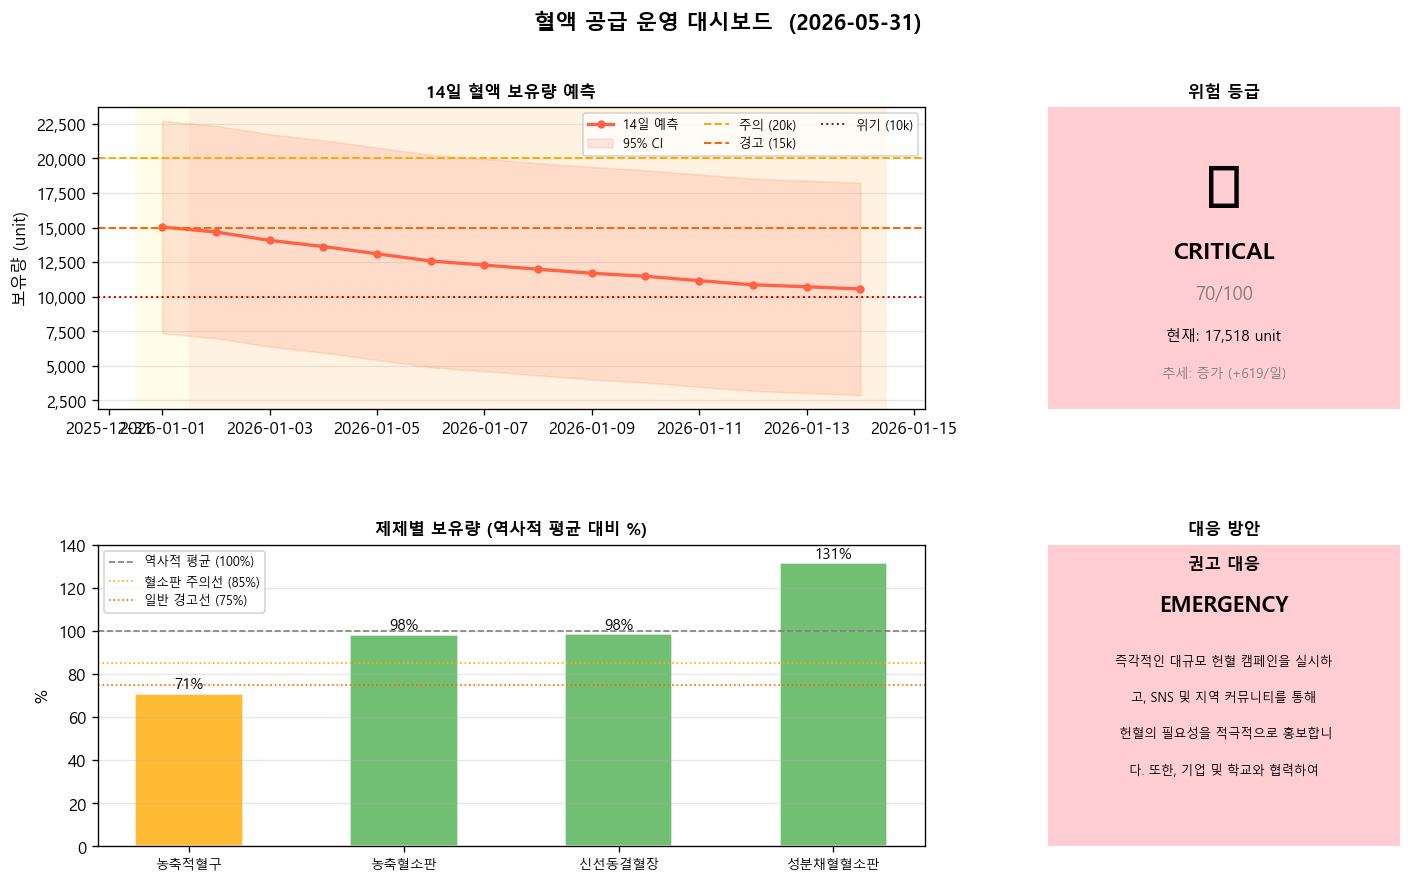

In [47]:
# ═══════════════════════════════════════════════════════════════════
#  파이프라인 실행 & 결과 시각화
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams['font.family']      = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']= False
plt.rcParams['figure.dpi']       = 120

print('═' * 52)
print('  혈액 부족 예측 & 헌혈 운영 최적화 에이전트 실행')
print('═' * 52)

# 초기 State
initial_state: BloodAgentState = {
    'run_date':            pd.Timestamp.now().strftime('%Y-%m-%d'),
    'current_inventory':   0,
    'last_data_date':      '',
    'trend_7d_direction':  '',
    'trend_7d_rate':       0.0,
    'current_season':      '',
    'is_risk_season':      False,
    'forecast_14d':        [],
    'forecast_min_value':  0,
    'forecast_min_date':   '',
    'shortage_probability':0.0,
    'days_until_warning':  14,
    'risk_level':          'NORMAL',
    'risk_score':          0,
    'component_risks':     {},
    'historical_context':  '',
    'intervention_level':  'NONE',
    'recommended_action':  '',
    'action_reasoning':    '',
    'final_report':        '',
}

# ── 실행 ────────────────────────────────────────────────────────
final_state = blood_agent_app.invoke(initial_state)

print('─' * 52)
print('✅ 전체 파이프라인 완료')

# ── 결과 시각화 ─────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 8))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

risk_colors_bg = {'NORMAL':'#e8f5e9','CAUTION':'#fff9c4','WARNING':'#ffe0b2','CRITICAL':'#ffcdd2'}
risk_level = final_state['risk_level']
risk_score = final_state['risk_score']

# ── (1) 14일 예측 차트 ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
fc_df    = pd.DataFrame(final_state['forecast_14d'])
fc_dates = pd.to_datetime(fc_df['date'])
fc_vals  = fc_df['forecast'].values

# 위험 등급 배경
risk_col_map = {'🟢 NORMAL':'#e8f5e9','🟡 CAUTION':'#fff9c4','🟠 WARNING':'#ffe0b2','🔴 CRITICAL':'#ffcdd2'}
for _, row in fc_df.iterrows():
    d     = pd.Timestamp(row['date'])
    color = risk_col_map.get(row.get('risk', ''), '#f5f5f5')
    ax1.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), alpha=0.4, color=color, lw=0)

ax1.plot(fc_dates, fc_vals, color='tomato', lw=2, marker='o', ms=4, label='14일 예측')
if 'lower_95' in fc_df.columns:
    ax1.fill_between(fc_dates, fc_df['lower_95'], fc_df['upper_95'], alpha=0.15, color='tomato', label='95% CI')
ax1.axhline(THRESHOLDS['CAUTION'],  color='#ffaa00', ls='--', lw=1.2, label='주의 (20k)')
ax1.axhline(THRESHOLDS['WARNING'],  color='#ff6600', ls='--', lw=1.2, label='경고 (15k)')
ax1.axhline(THRESHOLDS['CRITICAL'], color='#cc0000', ls=':',  lw=1.2, label='위기 (10k)')
ax1.set_title('14일 혈액 보유량 예측', fontsize=10, fontweight='bold')
ax1.set_ylabel('보유량 (unit)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax1.legend(fontsize=7.5, ncol=3)
ax1.grid(axis='y', alpha=0.3)

# ── (2) 위험 게이지 ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')
bg_color = risk_colors_bg.get(risk_level, '#ffffff')
ax2.set_facecolor(bg_color)
ax2.add_patch(plt.Rectangle((0,0),1,1, color=bg_color, transform=ax2.transAxes, zorder=0))
emoji = RISK_EMOJI.get(risk_level, '❓')
ax2.text(0.5, 0.72, emoji,        ha='center', va='center', fontsize=36, transform=ax2.transAxes)
ax2.text(0.5, 0.52, risk_level,   ha='center', va='center', fontsize=14, fontweight='bold', transform=ax2.transAxes)
ax2.text(0.5, 0.38, f'{risk_score}/100', ha='center', va='center', fontsize=11, color='gray', transform=ax2.transAxes)
ax2.text(0.5, 0.24, f"현재: {final_state['current_inventory']:,} unit",
         ha='center', va='center', fontsize=9, transform=ax2.transAxes)
ax2.text(0.5, 0.12, f"추세: {final_state['trend_7d_direction']} ({final_state['trend_7d_rate']:+.0f}/일)",
         ha='center', va='center', fontsize=8, color='gray', transform=ax2.transAxes)
ax2.set_title('위험 등급', fontsize=10, fontweight='bold')

# ── (3) 제제별 위험도 ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
comp = final_state['component_risks']
comp_names = list(comp.keys())
comp_ratios= [v['ratio'] * 100 for v in comp.values()]
comp_levels= [v['level'] for v in comp.values()]
bar_colors = ['#cc0000' if l=='CRITICAL' else '#ff6600' if l=='WARNING' else '#ffaa00' if l=='CAUTION' else '#4caf50'
              for l in comp_levels]
bars = ax3.bar(comp_names, comp_ratios, color=bar_colors, alpha=0.8, width=0.5, edgecolor='white')
ax3.axhline(100, color='gray', ls='--', lw=1, label='역사적 평균 (100%)')
ax3.axhline(85,  color='#ffaa00', ls=':', lw=1, label='혈소판 주의선 (85%)')
ax3.axhline(75,  color='#ff6600', ls=':', lw=1, label='일반 경고선 (75%)')
for bar, v in zip(bars, comp_ratios):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{v:.0f}%',
             ha='center', va='bottom', fontsize=9)
ax3.set_title('제제별 보유량 (역사적 평균 대비 %)', fontsize=10, fontweight='bold')
ax3.set_ylabel('%'); ax3.set_ylim(0, 140)
ax3.legend(fontsize=7.5); ax3.grid(axis='y', alpha=0.3)
comp_labels = {'RBC':'농축적혈구','PLT':'농축혈소판','FFP':'신선동결혈장','SDP':'성분채혈혈소판'}
ax3.set_xticklabels([comp_labels.get(n, n) for n in comp_names], fontsize=8)

# ── (4) 권고 대응 요약 ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')
action_color = {'NONE':'#e8f5e9','LOW':'#f1f8e9','MEDIUM':'#fff9c4',
                'HIGH':'#ffe0b2','EMERGENCY':'#ffcdd2'}.get(final_state.get('intervention_level','NONE'), '#fff')
ax4.set_facecolor(action_color)
ax4.add_patch(plt.Rectangle((0,0),1,1, color=action_color, transform=ax4.transAxes, zorder=0))
lvl   = final_state.get('intervention_level', 'NONE')
action= final_state.get('recommended_action', '')
lines = [action[i:i+20] for i in range(0, min(len(action), 80), 20)]
ax4.text(0.5, 0.92, '권고 대응',         ha='center', fontsize=10, fontweight='bold', transform=ax4.transAxes)
ax4.text(0.5, 0.78, lvl,                 ha='center', fontsize=13, fontweight='bold', transform=ax4.transAxes)
for i, line in enumerate(lines):
    ax4.text(0.5, 0.60 - i*0.12, line,  ha='center', fontsize=7.5, transform=ax4.transAxes)
ax4.set_title('대응 방안', fontsize=10, fontweight='bold')

fig.suptitle(f'혈액 공급 운영 대시보드  ({final_state["run_date"]})',
             fontsize=13, fontweight='bold')
plt.show()

---

## 참고: KOSIS API (실시간 데이터 수집)

CSV가 아닌 KOSIS Open API로 최신 데이터를 직접 받아오는 코드입니다.  
Phase 1 이후 에이전트의 Sensing 단계에서 사용합니다.

In [ ]:
import requests
import pandas as pd

# KOSIS에서 생성된 URL 그대로 사용
url = "https://kosis.kr/openapi/Param/statisticsParameterData.do"

params = {
    "method":       "getList",
    "apiKey":       "MDRiYjNmYWZlOTk1MDk0MGEzOTRkMmY2MTY1MmU3ZDc=",
    "itmId":        "T001 T002 ",
    "objL1":        "ALL",
    "objL2":        "ALL",
    "objL3":        "ALL",
    "objL4":        "",
    "objL5":        "",
    "objL6":        "",
    "objL7":        "",
    "objL8":        "",
    "format":       "json",
    "jsonVD":       "Y",
    "prdSe":        "M",
    "newEstPrdCnt": "10",
    "prdInterval":  "1",
    "orgId":        "445",
    "tblId":        "DT_445001_002"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)
print(df.head())
print(df.columns.tolist())

In [ ]:
import requests
import pandas as pd

API_KEY = "MDRiYjNmYWZlOTk1MDk0MGEzOTRkMmY2MTY1MmU3ZDc="
url = "https://kosis.kr/openapi/Param/statisticsParameterData.do"

params = {
    "method":       "getList",
    "apiKey":       API_KEY,
    "itmId":        "T001+T002+",
    "objL1":        "ALL",
    "objL2":        "ALL",
    "objL3":        "ALL",
    "objL4":        "", "objL5": "", "objL6": "", "objL7": "", "objL8": "",
    "format":       "json",
    "jsonVD":       "Y",
    "prdSe":        "M",
    "newEstPrdCnt": "120",
    "prdInterval":  "1",
    "orgId":        "445",
    "tblId":        "DT_445001_002"
}

response = requests.get(url, params=params)
df = pd.DataFrame(response.json())

df_clean = df[['PRD_DE', 'C1_NM', 'C2_NM', 'C3_NM', 'ITM_NM', 'DT', 'UNIT_NM']].copy()
df_clean['DT'] = pd.to_numeric(df_clean['DT'], errors='coerce')

print("샘플 데이터:")
print(df_clean.head(20))
print("\n월 범위:", sorted(df_clean['PRD_DE'].unique())[:10], "...")